# 02 EDA and Feature Engineering

Continues from `01_Data_Understanding.ipynb`. Loads the merged dataset, handles missing values, explores the data, removes redundant/near-duplicate columns via correlation analysis, and engineers new features for modeling.

## 1. Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import joblib
import os

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)

merged_df = pd.read_csv("../data/processed/merged_dataset.csv")
print("Shape:", merged_df.shape)
merged_df.head()

Shape: (51336, 87)


,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_utilization,CC_Flag,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,0,0,0.00,0.0,0,0,0,0,1,0,4,1,4,0,72,18,549,35,15,11,29,29,0,0,0,-99999,-99999,0,0,21,5,11,0,0,0,0,0,0,0,0,0,29,6,0,0,0,6,0,0,566,0,0,0,Married,12TH,48,M,51000,114,0.200,0.0,0.798,-99999.0,0,0.798,1,0.0,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,1,0,1.00,0.0,0,0,0,1,0,0,0,0,1,0,7,7,47,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,209,1,0,0,Single,GRADUATE,23,F,19000,50,1.000,0.0,0.370,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,2,0,0.25,0.0,1,1,0,6,1,0,0,2,6,0,47,2,302,11,3,9,25,25,1,9,8,25,25,0,0,10,5,10,0,0,0,0,0,0,0,0,0,25,4,0,0,0,0,0,0,587,0,0,0,Married,SSC,40,M,18,191,1.000,0.5,0.585,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,1,0,1.00,0.0,1,0,0,0,0,0,0,0,1,1,5,5,-99999,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,5,4,5,0,0,0,0,0,0,0,0,0,0,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,Married,SSC,34,M,10000,246,1.000,1.0,0.990,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,0,0,0.00,0.0,0,1,0,0,0,0,0,3,0,2,131,32,583,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,53,4,16,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,3951,0,0,0,Married,POST-GRADUATE,48,M,15000,75,0.333,0.0,0.000,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


## 2. Handle Sentinel Missing Values

This dataset (a common CIBIL/bureau case study) encodes missing values as `-99999` instead of `NaN`. We replace the sentinel, then measure real missingness.

In [2]:
# The data uses -99999 to mean "missing" (a common bureau-data trick). I swap every
# -99999 in the numeric columns for a real NaN so pandas can treat it as missing.
SENTINEL = -99999
num_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()
merged_df[num_cols] = merged_df[num_cols].replace(SENTINEL, np.nan)

# now measure how much is ACTUALLY missing in each column (as a %)
missing_pct = (merged_df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(f"{len(missing_pct)} columns have missing values after replacing the sentinel:")
missing_pct

23 columns have missing values after replacing the sentinel:


CC_utilization                  92.792582
PL_utilization                  86.557192
time_since_recent_deliquency    70.026882
max_delinquency_level           70.026882
time_since_first_deliquency     70.026882
max_unsec_exposure_inPct        45.149603
max_deliq_6mts                  25.109085
max_deliq_12mts                 21.100203
PL_enq_L12m                     12.312997
time_since_recent_enq           12.312997
enq_L3m                         12.312997
PL_enq                          12.312997
PL_enq_L6m                      12.312997
enq_L6m                         12.312997
CC_enq_L12m                     12.312997
CC_enq_L6m                      12.312997
CC_enq                          12.312997
tot_enq                         12.312997
enq_L12m                        12.312997
time_since_recent_payment        8.358657
pct_currentBal_all_TL            0.140252
Age_Oldest_TL                    0.077918
Age_Newest_TL                    0.077918
dtype: float64

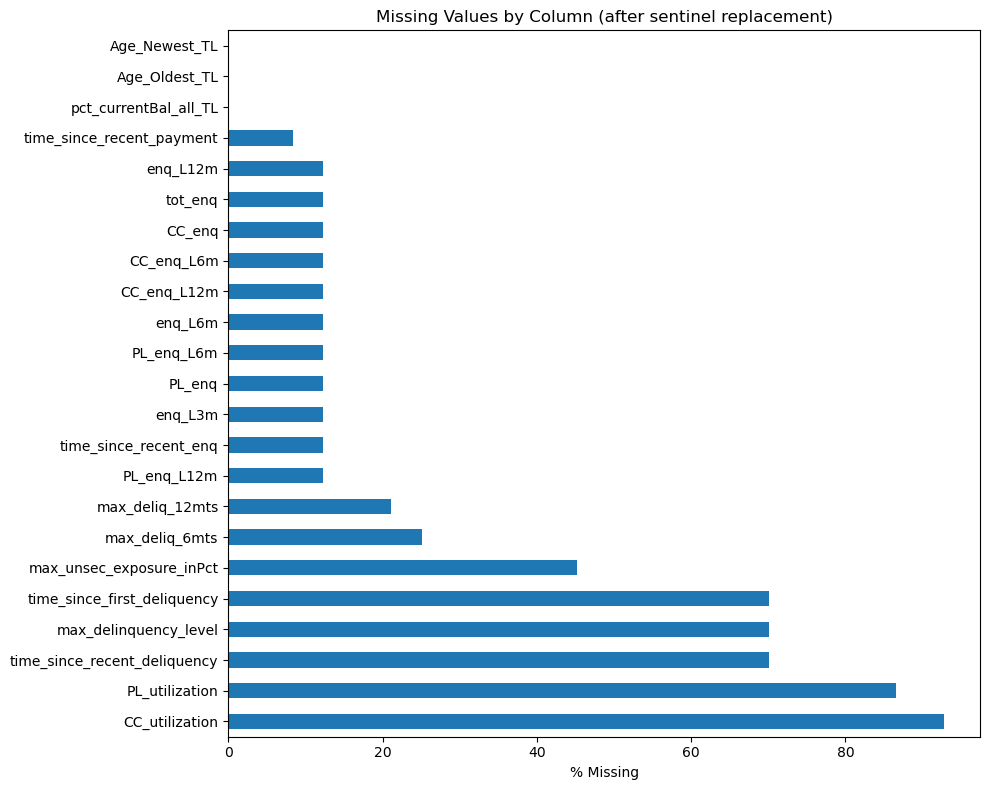

In [3]:
plt.figure(figsize=(10, 8))
missing_pct.plot(kind='barh')
plt.xlabel('% Missing')
plt.title('Missing Values by Column (after sentinel replacement)')
plt.tight_layout()
plt.savefig('../figures/missing_values.png', dpi=120)
plt.show()

Columns missing in more than 30% of rows carry too little signal to impute reliably (e.g. `CC_utilization`/`PL_utilization` are ~90% empty, and the delinquency-recency columns are ~70% empty because most customers have never been delinquent). We drop these rather than impute them.

In [4]:
# If a column is more than 30% empty, there's too little real data to trust it, so
# I drop it instead of guessing (imputing) most of its values.
MISSING_DROP_THRESHOLD = 30.0
missingness_drop_cols = missing_pct[missing_pct > MISSING_DROP_THRESHOLD].index.tolist()
print(f"Dropping {len(missingness_drop_cols)} columns for >{MISSING_DROP_THRESHOLD}% missing:")
print(missingness_drop_cols)

df = merged_df.drop(columns=missingness_drop_cols)
print("\nShape after missingness drop:", df.shape)

Dropping 6 columns for >30.0% missing:
['CC_utilization', 'PL_utilization', 'time_since_recent_deliquency', 'max_delinquency_level', 'time_since_first_deliquency', 'max_unsec_exposure_inPct']

Shape after missingness drop: (51336, 81)


## 3. Univariate EDA

Approved_Flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64


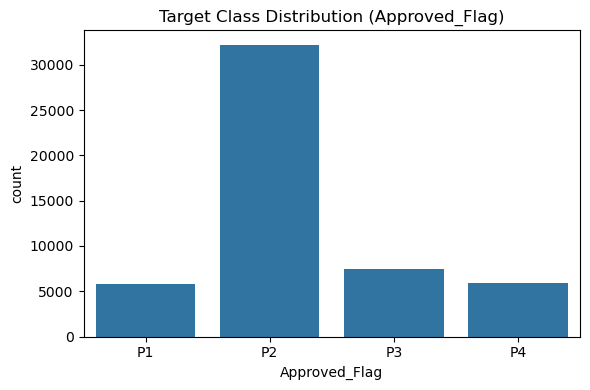

In [5]:
print(df['Approved_Flag'].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Approved_Flag', order=['P1', 'P2', 'P3', 'P4'])
plt.title('Target Class Distribution (Approved_Flag)')
plt.tight_layout()
plt.savefig('../figures/target_distribution.png', dpi=120)
plt.show()

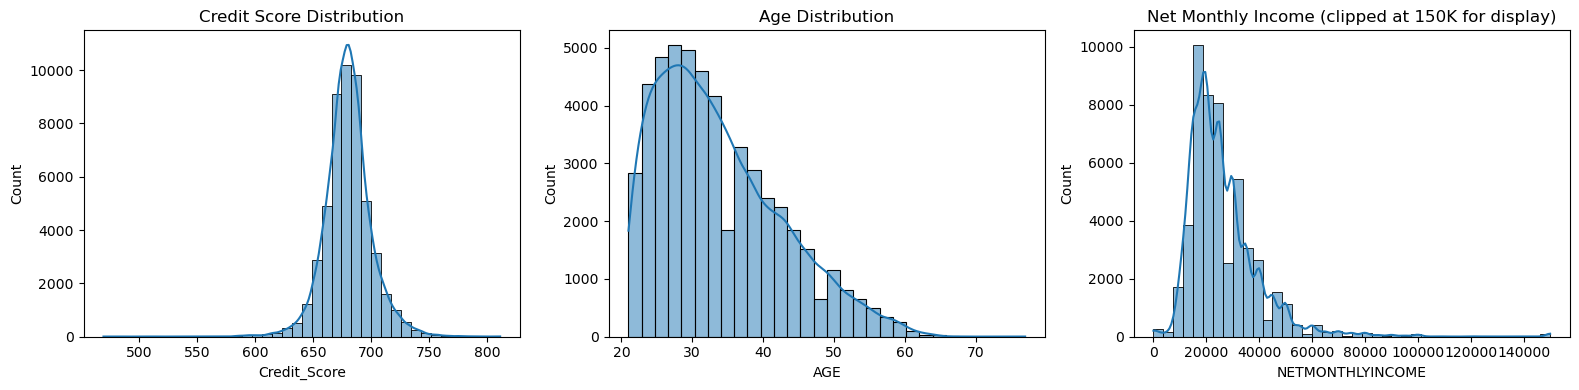

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['Credit_Score'], bins=40, ax=axes[0], kde=True)
axes[0].set_title('Credit Score Distribution')
sns.histplot(df['AGE'], bins=30, ax=axes[1], kde=True)
axes[1].set_title('Age Distribution')
sns.histplot(df['NETMONTHLYINCOME'].clip(upper=150000), bins=40, ax=axes[2], kde=True)
axes[2].set_title('Net Monthly Income (clipped at 150K for display)')
plt.tight_layout()
plt.savefig('../figures/univariate_distributions.png', dpi=120)
plt.show()

`NETMONTHLYINCOME` has clearly anomalous entries (e.g. a monthly income of 18) alongside legitimate high earners up to 25 lakh/month. These extremes would distort any income-based business logic downstream (loan sizing), so we winsorize (cap) income at the 1st/99th percentile for that purpose while keeping the raw column for reference.

In [7]:
print(df['NETMONTHLYINCOME'].describe())
print("\nRows with income < 1000:", (df['NETMONTHLYINCOME'] < 1000).sum())
print("Rows with income > 200000:", (df['NETMONTHLYINCOME'] > 200000).sum())

# "Winsorize" the income: clip the bottom 1% and top 1% of values so a few crazy
# entries (like Rs.18/month or 25 lakh/month) don't wreck the loan-sizing maths later.
# I keep the original column too and store the cleaned one as NETMONTHLYINCOME_Capped.
low, high = df['NETMONTHLYINCOME'].quantile([0.01, 0.99])
print(f"\nCapping income to [{low:,.0f}, {high:,.0f}]")
df['NETMONTHLYINCOME_Capped'] = df['NETMONTHLYINCOME'].clip(lower=low, upper=high)

count    5.133600e+04
mean     2.642419e+04
std      2.002711e+04
min      0.000000e+00
25%      1.800000e+04
50%      2.300000e+04
75%      3.000000e+04
max      2.500000e+06
Name: NETMONTHLYINCOME, dtype: float64

Rows with income < 1000: 184
Rows with income > 200000: 40

Capping income to [8,000, 78,000]


## 4. Bivariate EDA — Features vs. Target

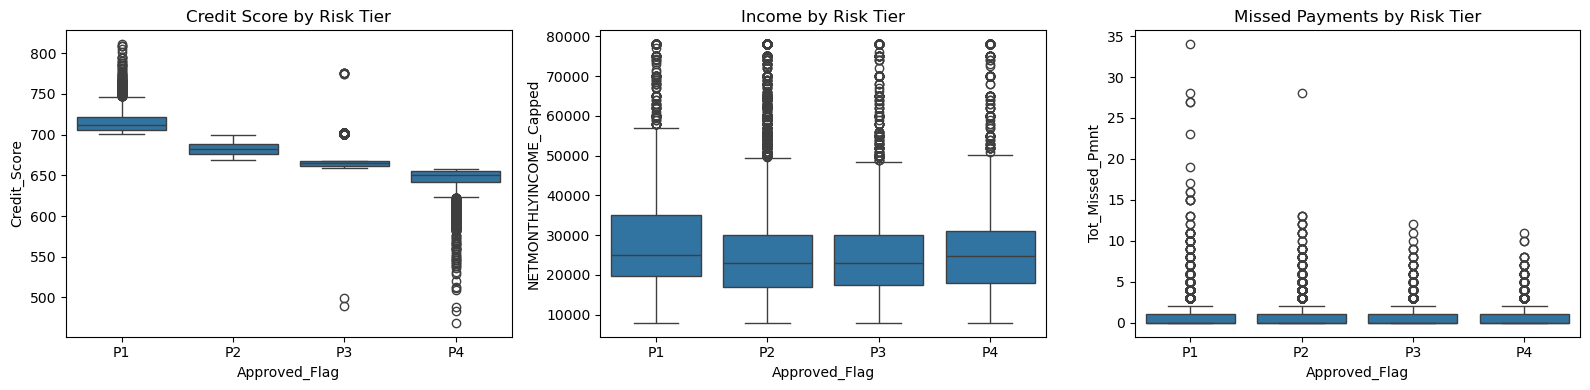

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df, x='Approved_Flag', y='Credit_Score', order=['P1','P2','P3','P4'], ax=axes[0])
sns.boxplot(data=df, x='Approved_Flag', y='NETMONTHLYINCOME_Capped', order=['P1','P2','P3','P4'], ax=axes[1])
sns.boxplot(data=df, x='Approved_Flag', y='Tot_Missed_Pmnt', order=['P1','P2','P3','P4'], ax=axes[2])
axes[0].set_title('Credit Score by Risk Tier')
axes[1].set_title('Income by Risk Tier')
axes[2].set_title('Missed Payments by Risk Tier')
plt.tight_layout()
plt.savefig('../figures/bivariate_boxplots.png', dpi=120)
plt.show()

In [9]:
from scipy.stats import chi2_contingency

# Chi-square test: checks whether a text column (like Education) is actually related
# to the target. A p-value below 0.05 means "yes, this column carries useful signal".
categorical_cols = ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']
print("Chi-square test of association with Approved_Flag:\n")
for c in categorical_cols:
    contingency = pd.crosstab(df[c], df['Approved_Flag'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    print(f"{c:20s} chi2={chi2:10.2f}  p-value={p:.4g}  {'(significant)' if p < 0.05 else ''}")

Chi-square test of association with Approved_Flag:

MARITALSTATUS        chi2=   1188.13  p-value=2.759e-257  (significant)
EDUCATION            chi2=    225.25  p-value=8.465e-38  (significant)
GENDER               chi2=     19.23  p-value=0.0002451  (significant)
last_prod_enq2       chi2=   3728.51  p-value=0  (significant)
first_prod_enq2      chi2=   1833.12  p-value=0  (significant)


## 5. Correlation Analysis — Drop or Merge Redundant Columns

The bureau feature set has many near-duplicate columns (e.g. a metric reported at both 6-month and 12-month windows, or a percentage and its complement). We flag numeric pairs with |correlation| > 0.9 and keep only the first-appearing column in each redundant group.

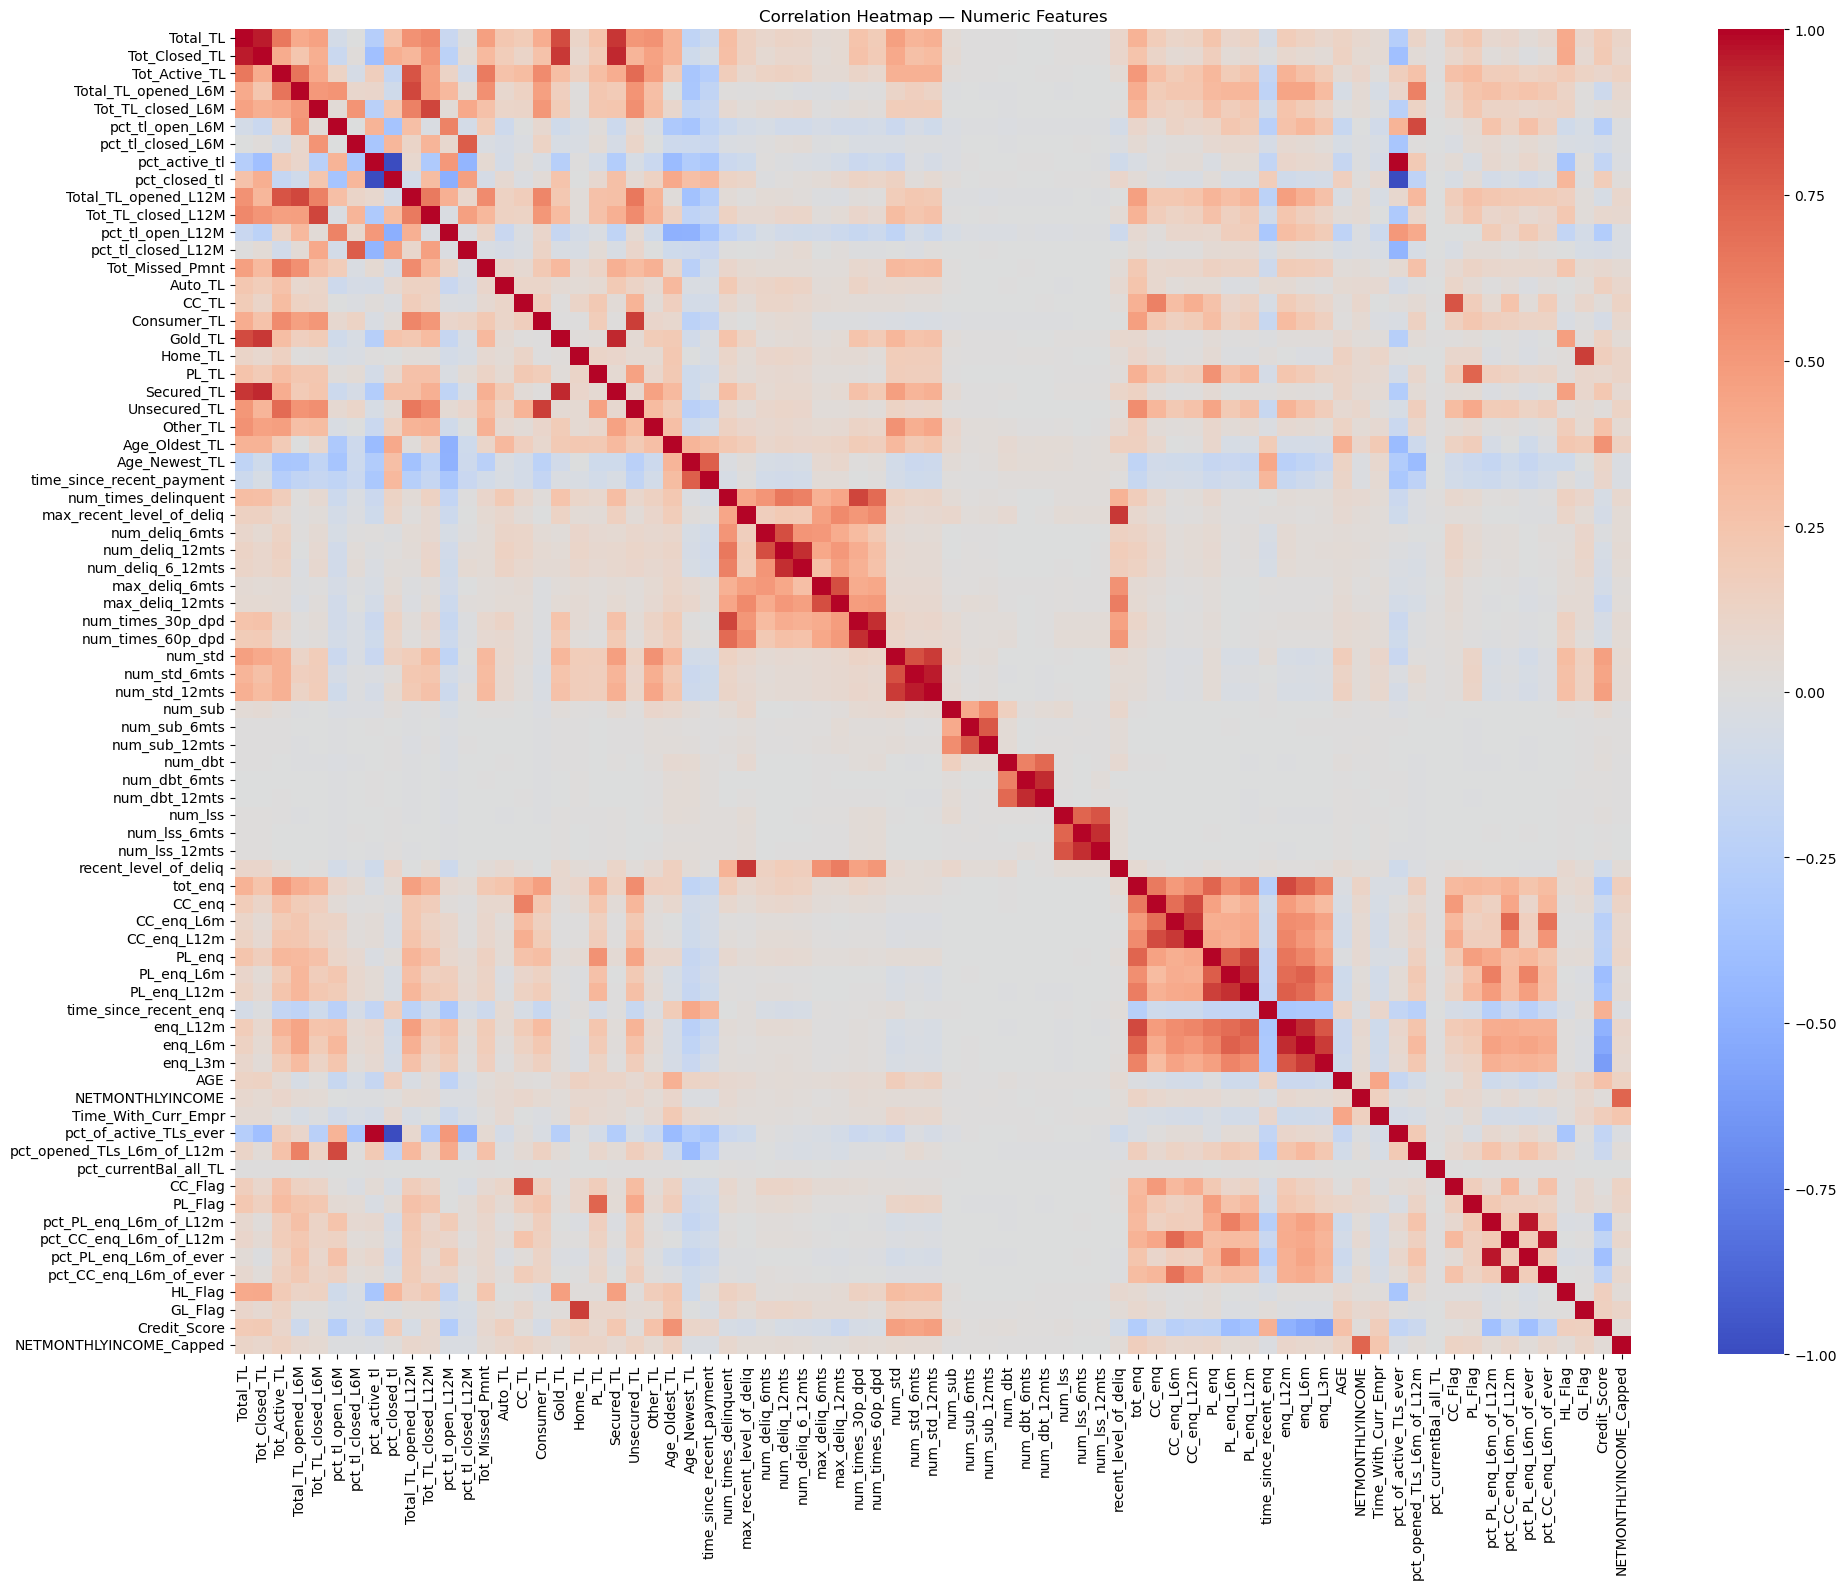

In [10]:
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'PROSPECTID']
corr = df[numeric_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, cmap='coolwarm', center=0, xticklabels=True, yticklabels=True)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig('../figures/correlation_heatmap.png', dpi=120)
plt.show()

In [11]:
# If two columns are almost the same (correlation above 0.9) they carry duplicate
# information, which can confuse the model. I look at the upper triangle of the
# correlation matrix (each pair once) and mark the extra column in each pair for removal.
CORR_THRESHOLD = 0.9
abs_corr = corr.abs()
upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))

redundant_pairs = []
for col in upper.columns:
    high_corr = upper[col][upper[col] > CORR_THRESHOLD]
    for other, val in high_corr.items():
        redundant_pairs.append((other, col, round(val, 3)))

print(f"{len(redundant_pairs)} column pairs correlated above {CORR_THRESHOLD}:")
for pair in redundant_pairs:
    print(" ", pair)

# Keep the first-appearing column of each correlated group, drop the later duplicate
corr_drop_cols = {col for col in upper.columns if (upper[col] > CORR_THRESHOLD).any()}
print(f"\n{len(corr_drop_cols)} columns dropped as redundant:")
print(sorted(corr_drop_cols))

15 column pairs correlated above 0.9:
  ('Total_TL', 'Tot_Closed_TL', 0.956)
  ('pct_active_tl', 'pct_closed_tl', 1.0)
  ('Tot_Closed_TL', 'Secured_TL', 0.931)
  ('Gold_TL', 'Secured_TL', 0.931)
  ('num_deliq_12mts', 'num_deliq_6_12mts', 0.917)
  ('num_times_30p_dpd', 'num_times_60p_dpd', 0.92)
  ('num_std_6mts', 'num_std_12mts', 0.958)
  ('num_dbt_6mts', 'num_dbt_12mts', 0.927)
  ('num_lss_6mts', 'num_lss_12mts', 0.917)
  ('PL_enq_L6m', 'PL_enq_L12m', 0.908)
  ('enq_L12m', 'enq_L6m', 0.923)
  ('pct_active_tl', 'pct_of_active_TLs_ever', 1.0)
  ('pct_closed_tl', 'pct_of_active_TLs_ever', 1.0)
  ('pct_PL_enq_L6m_of_L12m', 'pct_PL_enq_L6m_of_ever', 0.965)
  ('pct_CC_enq_L6m_of_L12m', 'pct_CC_enq_L6m_of_ever', 0.962)

13 columns dropped as redundant:
['PL_enq_L12m', 'Secured_TL', 'Tot_Closed_TL', 'enq_L6m', 'num_dbt_12mts', 'num_deliq_6_12mts', 'num_lss_12mts', 'num_std_12mts', 'num_times_60p_dpd', 'pct_CC_enq_L6m_of_ever', 'pct_PL_enq_L6m_of_ever', 'pct_closed_tl', 'pct_of_active_TLs_ever

In [12]:
df = df.drop(columns=[c for c in corr_drop_cols if c in df.columns])
print("Shape after correlation-based drop:", df.shape)

total_dropped = set(missingness_drop_cols) | corr_drop_cols
print(f"\nTOTAL COLUMNS DROPPED/DE-DUPLICATED THIS NOTEBOOK: {len(total_dropped)}")
print(sorted(total_dropped))

Shape after correlation-based drop: (51336, 69)

TOTAL COLUMNS DROPPED/DE-DUPLICATED THIS NOTEBOOK: 19
['CC_utilization', 'PL_enq_L12m', 'PL_utilization', 'Secured_TL', 'Tot_Closed_TL', 'enq_L6m', 'max_delinquency_level', 'max_unsec_exposure_inPct', 'num_dbt_12mts', 'num_deliq_6_12mts', 'num_lss_12mts', 'num_std_12mts', 'num_times_60p_dpd', 'pct_CC_enq_L6m_of_ever', 'pct_PL_enq_L6m_of_ever', 'pct_closed_tl', 'pct_of_active_TLs_ever', 'time_since_first_deliquency', 'time_since_recent_deliquency']


## 6. Impute Remaining Missing Values

The surviving columns have modest missingness (<=25%), coming from customers with no enquiry or delinquency history at all — median/mode imputation is appropriate here.

In [13]:
# The columns we kept still have a few gaps. I fill them in ("impute") so the model
# never sees a blank: numbers get the column's median, text gets the most common value.
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
print("Remaining missing values to impute:")
print(remaining_missing)

for c in remaining_missing.index:
    if df[c].dtype.kind in "iuf":         # i/u/f = integer/unsigned/float => a number
        df[c] = df[c].fillna(df[c].median())
    else:                                  # otherwise it's text => use the mode
        df[c] = df[c].fillna(df[c].mode()[0])

assert df.isnull().sum().sum() == 0
print("\nNo missing values remain.")

Remaining missing values to impute:
max_deliq_6mts               12890
max_deliq_12mts              10832
tot_enq                       6321
CC_enq                        6321
CC_enq_L6m                    6321
CC_enq_L12m                   6321
PL_enq                        6321
PL_enq_L6m                    6321
time_since_recent_enq         6321
enq_L12m                      6321
enq_L3m                       6321
time_since_recent_payment     4291
pct_currentBal_all_TL           72
Age_Oldest_TL                   40
Age_Newest_TL                   40
dtype: int64

No missing values remain.


## 7. Feature Engineering

**Reporting-only bins** (`Age_Group`, `Income_Segment`, `Credit_Score_Band`) make later business-facing tables and charts readable, but are deliberately *not* fed into the ML models — they're just bucketed versions of numeric columns (`AGE`, `NETMONTHLYINCOME_Capped`, `Credit_Score`) already present, so including both would just reintroduce the redundancy we removed above.

**Model features** (`Income_TL_Ratio`, `Credit_Health_Score`) are genuinely new signal derived from combining multiple raw columns.

In [14]:
# Reporting-only bins
df['Age_Group'] = pd.cut(df['AGE'], bins=[0,24,34,44,54,64,200],
                          labels=['18-24','25-34','35-44','45-54','55-64','65+'])
df['Income_Segment'] = pd.cut(df['NETMONTHLYINCOME_Capped'], bins=[-1,15000,30000,60000,100000,np.inf],
                               labels=['Low (<15K)','Lower-Mid (15K-30K)','Mid (30K-60K)',
                                       'Upper-Mid (60K-100K)','High (100K+)'])
df['Credit_Score_Band'] = pd.cut(df['Credit_Score'], bins=[-1,649,699,749,900],
                                  labels=['Poor (<650)','Fair (650-699)','Good (700-749)','Excellent (750+)'])

print(df['Age_Group'].value_counts())
print()
print(df['Income_Segment'].value_counts())
print()
print(df['Credit_Score_Band'].value_counts())

Age_Group
25-34    23608
35-44    13679
18-24     7210
45-54     5608
55-64     1225
65+          6
Name: count, dtype: int64

Income_Segment
Lower-Mid (15K-30K)     29278
Mid (30K-60K)           11284
Low (<15K)               9663
Upper-Mid (60K-100K)     1111
High (100K+)                0
Name: count, dtype: int64

Credit_Score_Band
Fair (650-699)      41764
Good (700-749)       6703
Poor (<650)          2704
Excellent (750+)      165
Name: count, dtype: int64


In [15]:
# Model feature 1: Income_TL_Ratio -- income per active trade line
# (higher = more income relative to the number of credit obligations = healthier)
df['Income_TL_Ratio'] = (df['NETMONTHLYINCOME_Capped'] / df['Tot_Active_TL'].replace(0, 1)).round(2)

# Model feature 2: Credit_Health_Score -- a 0-100 composite of positive and
# negative credit behaviors, independent of the raw Credit_Score
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

positive = (
    0.5 * minmax(df['Credit_Score']) +
    0.3 * minmax(df['Age_Oldest_TL']) +
    0.2 * minmax(1 - (df['Tot_Missed_Pmnt'] / df['Total_TL'].replace(0, 1)))
)
negative = (
    0.4 * minmax(df['Tot_Missed_Pmnt']) +
    0.35 * minmax(df['num_times_delinquent']) +
    0.25 * minmax(df['num_times_30p_dpd'])
)
df['Credit_Health_Score'] = ((positive - 0.5 * negative).clip(lower=0) * 100).round(2)

print(df[['Income_TL_Ratio', 'Credit_Health_Score']].describe())

       Income_TL_Ratio  Credit_Health_Score
count     51336.000000         51336.000000
mean      17605.656424            50.773292
std       12189.792943             8.206235
min         486.490000             5.950000
25%        8333.330000            47.850000
50%       15000.000000            51.540000
75%       24000.000000            55.150000
max       78000.000000            91.970000


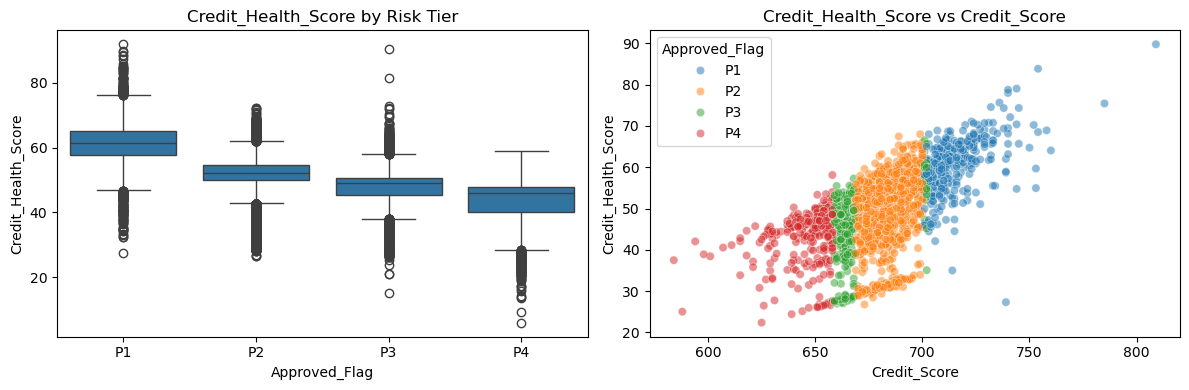

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='Approved_Flag', y='Credit_Health_Score', order=['P1','P2','P3','P4'], ax=axes[0])
axes[0].set_title('Credit_Health_Score by Risk Tier')
sns.scatterplot(data=df.sample(3000, random_state=1), x='Credit_Score', y='Credit_Health_Score',
                 hue='Approved_Flag', hue_order=['P1','P2','P3','P4'], alpha=0.5, ax=axes[1])
axes[1].set_title('Credit_Health_Score vs Credit_Score')
plt.tight_layout()
plt.savefig('../figures/engineered_features.png', dpi=120)
plt.show()

## 8. Encode Categorical Features

The five true categoricals (no numeric counterpart) are label-encoded for modeling. Encoders are saved so the same mapping can be reused when scoring the unseen dataset in notebook 04.

In [17]:
# Models only understand numbers, not text. LabelEncoder turns each text category
# into a number (e.g. Male->1, Female->0). I save the encoders so I can apply the
# EXACT same mapping later when scoring new/unseen applicants in notebook 04.
cat_cols = ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    df[c + '_enc'] = le.fit_transform(df[c].astype(str))   # new "_enc" numeric column
    encoders[c] = le
    print(c, '->', dict(zip(le.classes_, le.transform(le.classes_))))

os.makedirs('../models', exist_ok=True)
joblib.dump(encoders, '../models/label_encoders.joblib')
print("\nSaved label encoders to ../models/label_encoders.joblib")

MARITALSTATUS -> {'Married': np.int64(0), 'Single': np.int64(1)}
EDUCATION -> {'12TH': np.int64(0), 'GRADUATE': np.int64(1), 'OTHERS': np.int64(2), 'POST-GRADUATE': np.int64(3), 'PROFESSIONAL': np.int64(4), 'SSC': np.int64(5), 'UNDER GRADUATE': np.int64(6)}
GENDER -> {'F': np.int64(0), 'M': np.int64(1)}
last_prod_enq2 -> {'AL': np.int64(0), 'CC': np.int64(1), 'ConsumerLoan': np.int64(2), 'HL': np.int64(3), 'PL': np.int64(4), 'others': np.int64(5)}
first_prod_enq2 -> {'AL': np.int64(0), 'CC': np.int64(1), 'ConsumerLoan': np.int64(2), 'HL': np.int64(3), 'PL': np.int64(4), 'others': np.int64(5)}

Saved label encoders to ../models/label_encoders.joblib


## 9. Save Featured Dataset

In [18]:
print("Final shape:", df.shape)
print("\nFinal columns:")
print(list(df.columns))

os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/featured_dataset.csv', index=False)
print("\nSaved to ../data/processed/featured_dataset.csv")

Final shape: (51336, 79)

Final columns:
['PROSPECTID', 'Total_TL', 'Tot_Active_TL', 'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M', 'pct_tl_closed_L6M', 'pct_active_tl', 'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL', 'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'num_times_delinquent', 'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts', 'max_deliq_6mts', 'max_deliq_12mts', 'num_times_30p_dpd', 'num_std', 'num_std_6mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_lss', 'num_lss_6mts', 'recent_level_of_deliq', 'tot_enq', 'CC_enq', 'CC_enq_L6m', 'CC_enq_L12m', 'PL_enq', 'PL_enq_L6m', 'time_since_recent_enq', 'enq_L12m', 'enq_L3m', 'MARITALSTATUS', 'EDUCATION', 'AGE', 'GENDER', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr', 'pct_opened_TLs_L6m_of_L12m', 'pct_curre


Saved to ../data/processed/featured_dataset.csv


## 10. EDA Summary

Key findings, written out for the project report.

In [19]:
summary_lines = [
    "# EDA & Feature Engineering Summary",
    "",
    f"- Merged dataset: {merged_df.shape[0]:,} rows x {merged_df.shape[1]} columns "
    f"(inner join of Internal_Bank_Dataset and External_Cibil_Dataset on PROSPECTID).",
    f"- Target `Approved_Flag` distribution: {df['Approved_Flag'].value_counts().to_dict()}.",
    f"- Dropped {len(missingness_drop_cols)} columns for >{MISSING_DROP_THRESHOLD}% missing "
    f"(mostly utilization and delinquency-recency fields that don't apply to "
    f"customers with no such history): {missingness_drop_cols}.",
    f"- Dropped {len(corr_drop_cols)} further columns as redundant duplicates "
    f"(|correlation| > {CORR_THRESHOLD} with another retained column): {sorted(corr_drop_cols)}.",
    f"- Total columns removed: {len(total_dropped)} (from {merged_df.shape[1]} down to "
    f"{df.shape[1] - 7} pre-encoding feature columns).",
    "- `NETMONTHLYINCOME` contains data-entry outliers (values as low as single digits and "
    "as high as 25 lakh/month); capped at the 1st/99th percentile as `NETMONTHLYINCOME_Capped` "
    "for use in business calculations.",
    "- Engineered features: `Income_TL_Ratio`, `Credit_Health_Score` (model features), "
    "plus `Age_Group`, `Income_Segment`, `Credit_Score_Band` (reporting-only bins).",
    "- All 5 categorical columns show a statistically significant association with "
    "`Approved_Flag` (chi-square p < 0.05).",
]
os.makedirs('../reports', exist_ok=True)
with open('../reports/eda_summary.md', 'w') as f:
    f.write("\n".join(summary_lines))

print("\n".join(summary_lines))

# EDA & Feature Engineering Summary

- Merged dataset: 51,336 rows x 87 columns (inner join of Internal_Bank_Dataset and External_Cibil_Dataset on PROSPECTID).
- Target `Approved_Flag` distribution: {'P2': 32199, 'P3': 7452, 'P4': 5882, 'P1': 5803}.
- Dropped 6 columns for >30.0% missing (mostly utilization and delinquency-recency fields that don't apply to customers with no such history): ['CC_utilization', 'PL_utilization', 'time_since_recent_deliquency', 'max_delinquency_level', 'time_since_first_deliquency', 'max_unsec_exposure_inPct'].
- Dropped 13 further columns as redundant duplicates (|correlation| > 0.9 with another retained column): ['PL_enq_L12m', 'Secured_TL', 'Tot_Closed_TL', 'enq_L6m', 'num_dbt_12mts', 'num_deliq_6_12mts', 'num_lss_12mts', 'num_std_12mts', 'num_times_60p_dpd', 'pct_CC_enq_L6m_of_ever', 'pct_PL_enq_L6m_of_ever', 'pct_closed_tl', 'pct_of_active_TLs_ever'].
- Total columns removed: 19 (from 87 down to 72 pre-encoding feature columns).
- `NETMONTHLYINCOME` c